In [40]:
#load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

apps = pd.read_csv('/content/apps.csv')
reviews =pd.read_csv('/content/user_reviews.csv')
print(apps.shape,reviews.shape)
apps.head()
reviews.head()

(9659, 14) (64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [41]:
#clean data
# drop duplicates from data
apps.drop_duplicates(inplace=True)

# drop unnecessary column
apps.drop('Unnamed: 0',axis=1,inplace=True)
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [42]:
#handle missing values

apps.dropna(subset=['Rating'],inplace=True)
apps.isnull().sum()


,0
App,0
Category,0
Rating,0
Reviews,0
Size,1169
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [43]:
#clean installs column

apps['Installs'] = apps['Installs'].str.replace('[+,]','', regex = True).astype(int)

#clean price column
apps['Price'] = apps['Price'].str.replace('[$,]','', regex = True).astype(float)
print(apps.shape)
apps.head()


(8196, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


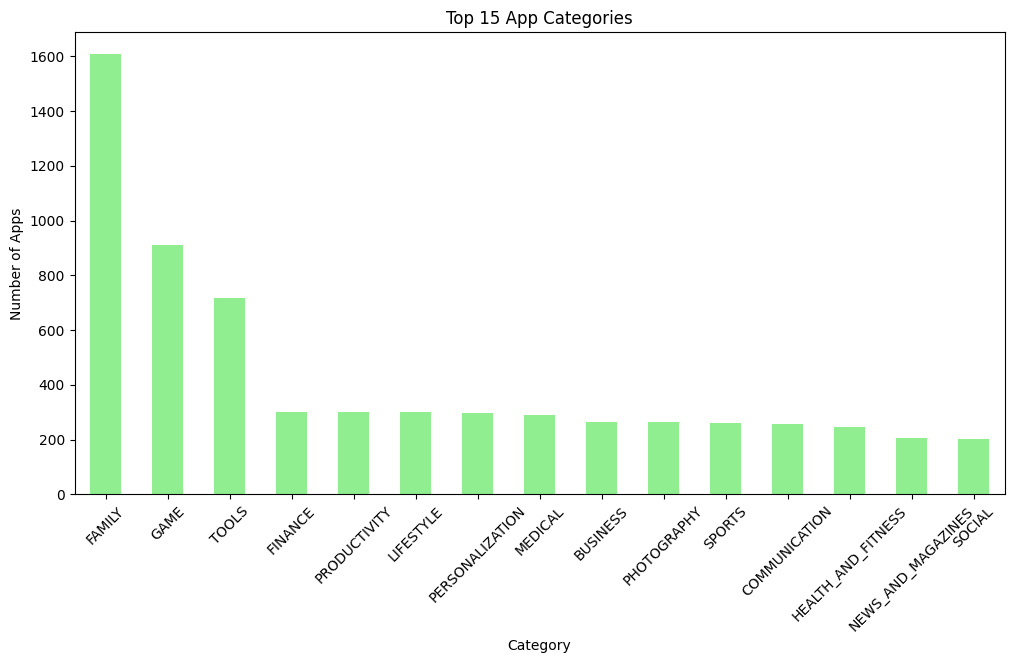

In [49]:
#category distribution
plt.figure(figsize=(12,6))
apps['Category'].value_counts().head(15).plot(kind='bar', color='lightgreen')
plt.title('Top 15 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.show()

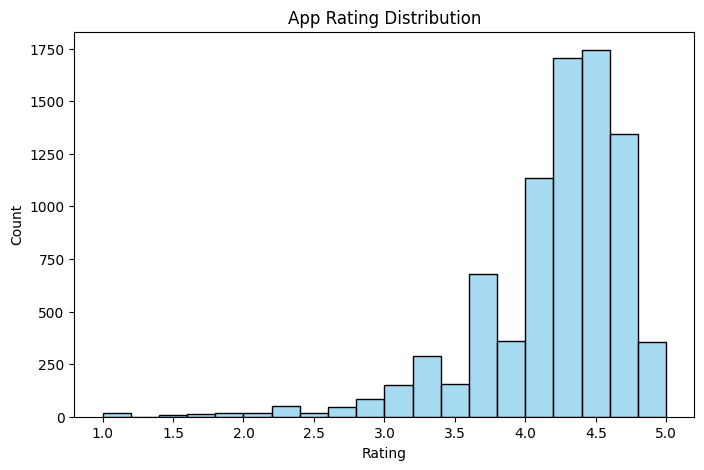

In [50]:
#rating distribution
plt.figure(figsize=(8,5))
sns.histplot(apps['Rating'], bins=20, color='skyblue')
plt.title('App Rating Distribution')
plt.xlabel('Rating')
plt.show()

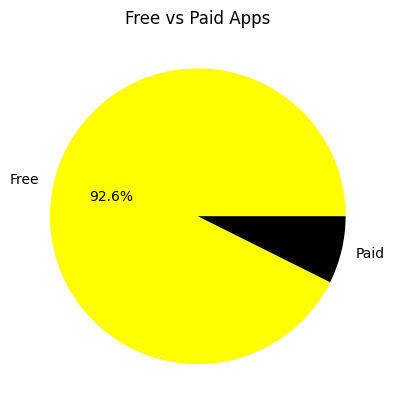

In [53]:
#free vs paid apps

apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                  colors=['yellow','black'])
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()


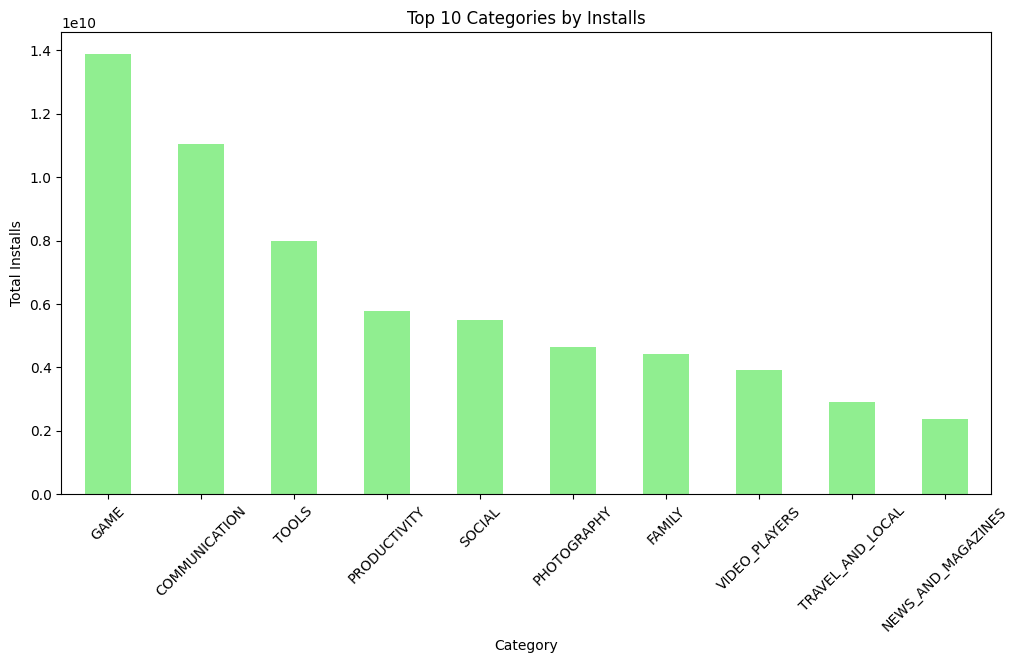

In [54]:
# top categories by installs
plt.figure(figsize=(12,6))
apps.groupby('Category')['Installs'].sum().sort_values(
    ascending=False).head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Categories by Installs')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)
plt.show()

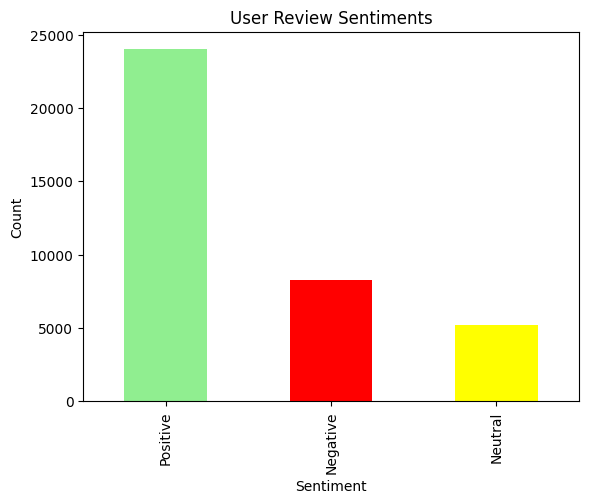

In [55]:
#sentiments analysis from reviews
reviews['Sentiment'].value_counts().plot(kind='bar',
                                          color=['lightgreen','red','yellow'])
plt.title('User Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Android App Market Analysis

#Dataset
- 9659 apps across multiple categories
- 64295 user reviews with sentiment data

#Key Findings
- Most apps belong to Family and Game categories
- 92% of apps are Free, only 8% are Paid
- Average app rating is around 4.1 out of 5
- Communication and Social apps have highest installs


#Conclusion
The Android app market is dominated by free apps.
Gaming and Family categories have most apps
High ratings and free pricing drives more installs.